Alright, here's our plan:
* Take a pre-trained inception v3 to vectorize images
* Stack an LSTM on top of it
* Train the thing on MSCOCO

## Importing stuff and preparing data

In [7]:
%%time

# Load dataset (vectorized images and captions)
import numpy as np
import json

img_codes = np.load("data/image_codes.npy")
captions = json.load(open('data/captions_tokenized.json'))

Wall time: 5.94 s


In [8]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


As you can see, all captions are already tokenized and lowercased. We now want to split them and add some special tokens for start/end of caption.

In [9]:
# split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i] 
        captions[img_i][caption_i] = ["#START#"] + sentence.split(' ') + ["#END#"]

You don't want your network to predict a million-size vector of probabilities at each step, so we're gotta make some cuts.

We want you to count the occurences of each word so that we can decide which words to keep in our vocabulary.

In [10]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()
tokens = []

# Compute word frequencies for each word in captions. See code above for data structure
for i in range(len(captions)):
  for j in range(len(captions[i])):
    tokens += captions[i][j]

word_counts = Counter(tokens)

In [11]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [12]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))
    
    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix
    
    return matrix

In [7]:
# Try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]])

## Building our neural network
As we mentioned earlier, we shall build an rnn "language-model" conditioned on vectors from the convolutional part.


In [13]:
import torch
from torch import nn
import torch.nn.functional as F

from caption_net import CaptionNet
from utils import compute_loss

In [14]:
network = CaptionNet(n_tokens)
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [15]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix, pad_ix)

assert len(dummy_loss.shape) <= 1, 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
    'loss should depend differentiably on all neural network weights'

## Batch generator

In [17]:
from sklearn.model_selection import train_test_split

captions = np.array(captions)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(
    img_codes, captions, test_size=0.1, random_state=42
)

In [18]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):
    
    # sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)
    
    # get images
    batch_images = img_codes[random_image_ix]
    
    # 5-7 captions for each image
    captions_for_batch_images = captions[random_image_ix]
    
    # pick one from a set of captions for each image
    batch_captions = list(map(choice,captions_for_batch_images))
    
    # convert to matrix
    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)
    
    return torch.tensor(batch_images, dtype=torch.float32), \
        torch.tensor(batch_captions_ix, dtype=torch.int64)

In [19]:
generate_batch(img_codes, captions, 3)

(tensor([[0.7106, 0.1727, 0.4682,  ..., 0.0232, 0.1226, 0.3827],
         [0.0767, 0.0508, 0.2091,  ..., 0.8003, 0.4193, 0.0044],
         [0.0075, 0.4037, 0.1431,  ..., 0.1669, 0.0231, 0.0000]]),
 tensor([[   1,   24,  610,   58,   24, 2306,  612,    6,  159,   14,  620,  785,
            12,    2,    3,    3,    3,    3,    3,    3],
         [   1,  351,  699,   14, 2453,  209,   58,   24,  293,   35,   24,   71,
             2,    3,    3,    3,    3,    3,    3,    3],
         [   1,  392, 1498,   18,   45,  331,   14,   24,  103,  480, 6793,    4,
          1652,  163, 5689, 3462,  495, 6527,   12,    2]]))

## Train and validate loop

In [20]:
from tqdm import tqdm_notebook
from tqdm import tqdm
from IPython.display import clear_output

In [21]:
DEVICE = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')

In [22]:
DEVICE

device(type='cuda', index=0)

## Generating caption

The function below creates captions by sampling from probabilities defined by the net.

The implementation used here is simple but inefficient (quadratic in lstm steps). We keep it that way since it isn't a performance bottleneck.

In [30]:
from beheaded_inception3 import beheaded_inception_v3

inception = beheaded_inception_v3().eval()

def generate_caption(network, image, caption_prefix = ('#START#',), t=1, sample=True, max_len=100):
    network = network.cpu().eval()

    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >= 0 and image.shape[-1] == 3
    
    image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)
    
    vectors_8x8, vectors_neck, logits = inception(image[None])
    caption_prefix = list(caption_prefix)
    
    for _ in range(max_len):
        
        prefix_ix = as_matrix([caption_prefix])
        prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
        next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
        next_word_probs = F.softmax(next_word_logits, -1).detach().numpy()
        
        assert len(next_word_probs.shape) == 1, 'probs must be one-dimensional'
        next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

        if sample:
            next_word = np.random.choice(vocab, p=next_word_probs) 
        else:
            next_word = vocab[np.argmax(next_word_probs)]

        caption_prefix.append(next_word)

        if next_word == '#END#':
            break

    return ' '.join(caption_prefix[1:-1])

C:\Program Files\Python38\lib\site-packages\torchvision\models\inception.py:81: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn('The default weight initialization of inception_v3 will be changed in future releases of '


In [31]:
import matplotlib.pyplot as plt
from skimage.transform import resize

## Images to test on

We have downloaded 30 images from validation set of MSCOCO, they are located in `data` folder and named `img_i.jpg` for i from 0 to 29. You should use them to measure your network quality during checkpoints.

In [32]:
### READ IMAGES FROM DISK
imgs = []

for i in range(30):
    image = plt.imread("data/img_" + str(i) + ".jpg")
    image = resize(image, (299, 299))
    imgs.append(image)

In [33]:
import random

def generate_batches_for_epoch(img_codes, captions, batch_size, max_caption_len=None):
    random_image_ix_all = list(range(len(img_codes)))
    random.shuffle(random_image_ix_all)

    batches = list()

    batch_count = len(img_codes) // batch_size

    for i in range(batch_count):
        random_image_ix = random_image_ix_all[i * batch_size : (i + 1) * batch_size]

        batch_images = img_codes[random_image_ix]
        captions_for_batch_images = captions[random_image_ix]
        batch_captions = list(map(choice,captions_for_batch_images))
        batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

        batches.append((torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)))

    return batches

def generate_val_batches_for_epoch(img_codes, captions, batch_size, max_caption_len=None):
    image_ix_all = list(range(len(img_codes)))

    batches = list()
    batch_count = len(img_codes) // batch_size

    for i in range(batch_count):
        if ((i + 2) * batch_size >= len(image_ix_all)):
            random_image_ix = image_ix_all[i * batch_size : len(image_ix_all)-1]
        else:
            random_image_ix = image_ix_all[i * batch_size : (i + 1) * batch_size]

        batch_images = img_codes[random_image_ix]
        captions_for_batch_images = captions[random_image_ix]
        batch_captions = list(map(choice,captions_for_batch_images))
        batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

        batches.append((torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)))

    return batches

In [36]:
def train_net(network, optimizer, batch_size, n_epochs, history_t=[], history_v=[]):
    for epoch in range(n_epochs):
        train_loss = 0
        network.train()
        batches = generate_batches_for_epoch(train_img_codes, train_captions, batch_size)
        for i in tqdm(range(len(batches))):
            images, captions = batches[i]
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)

            loss_t = compute_loss(network, images, captions, pad_ix)
            
            # clear old gradients; do a backward pass to get new gradients; then train with opt
            # YOUR CODE HERE
            optimizer.zero_grad()
            loss_t.backward()
            optimizer.step()
            
            train_loss += loss_t.detach().cpu().numpy()
            
        train_loss /= len(batches)
        history_t.append(train_loss)
        
        val_loss = 0
        network.eval()
        val_batches = generate_val_batches_for_epoch(val_img_codes, val_captions, batch_size)
        for i in range(len(val_batches)):
            images, captions = val_batches[i]
            images = images.to(DEVICE)
            captions = captions.to(DEVICE)
            
            with torch.no_grad():
                loss_t = compute_loss(network, images, captions, pad_ix)

            val_loss += loss_t.detach().cpu().numpy()

        val_loss /= len(val_batches)
        history_v.append(val_loss)
        
        clear_output()
        print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

    print("Finished!")
    return network

Let's train network for 20 epochs

In [37]:
network_best = CaptionNet(n_tokens).to(DEVICE)
optimizer = torch.optim.Adam(network_best.parameters(), lr=1e-3)

batch_size = 66
n_epochs = 20
network_best = train_net(network_best, optimizer, batch_size, n_epochs)


Epoch: 19, train loss: 2.2304334900649674, val loss: 2.402546116759657
Finished!


In [39]:
#i = 1
#for image in imgs:
#    plt.imshow(image)
#    plt.show()
#    print(i, generate_caption(network_best, image, t=5.))
#    i += 1

In [41]:
torch.save(network_best.state_dict(), 'network_result.bin')

In [14]:
import pickle
with open('word_to_index.pickle', 'wb') as f:
    pickle.dump(word_to_index, f)

### Here is independent part of notebook, used for debugging

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
from skimage.transform import resize
from utils import generate_caption

In [2]:
from caption_net import CaptionNet
restored_network = CaptionNet()
restored_network.load_state_dict(torch.load('network_result.bin'))

<All keys matched successfully>

In [3]:
with open('word_to_index.pickle', 'rb') as f:
    word_to_index = pickle.load(f)

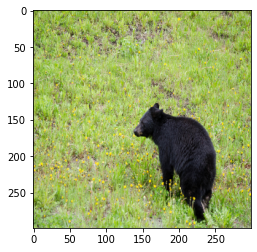

a black bear is standing in the grass .


In [4]:
image = plt.imread("data/img_1.jpg")
image = resize(image, (299, 299))
plt.imshow(image)
plt.show()
print(generate_caption(restored_network, word_to_index, image, t=5.))